In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля для LaTeX-совместимых графиков
plt.style.use('seaborn-v0_8-whitegrid')
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12
rcParams['figure.figsize'] = (12, 8)
rcParams['axes.titlesize'] = 16
rcParams['axes.labelsize'] = 14
rcParams['savefig.dpi'] = 300
rcParams['savefig.bbox'] = 'tight'

# Загрузка данных
print("📊 Загрузка данных...")
df = pd.read_csv('../data/final/ai_publics_dataset.csv', encoding='utf-8')
df['post_datetime'] = pd.to_datetime(df['post_datetime'])

# Создание папки для графиков
import os
os.makedirs('figures', exist_ok=True)

📊 Загрузка данных...


In [5]:
print("\n" + "="*60)
print("4.1. ОПИСАНИЕ ПОЛУЧЕННОГО ДАТАСЕТА")
print("="*60)

# Основная статистика
n_channels = df['channel_username'].nunique()
n_posts = len(df)
time_span = (df['post_datetime'].max() - df['post_datetime'].min()).days
mean_posts_per_channel = n_posts / n_channels
n_features = df.shape[1]
scheduled_posts_pct = (df['is_scheduled'].mean() * 100) if 'is_scheduled' in df.columns else 0
media_posts_pct = ((df['has_media'] == 1).mean() * 100) if 'has_media' in df.columns else 0
poll_posts_pct = ((df['has_poll'] == 1).mean() * 100) if 'has_poll' in df.columns else 0

print(f"\n📈 ОБЩАЯ СТАТИСТИКА:")
print(f"  • Количество каналов: {n_channels}")
print(f"  • Количество постов: {n_posts:,}")
print(f"  • Временной охват: {time_span} дней (~{time_span//365} лет)")
print(f"  • Среднее число постов на канал: {mean_posts_per_channel:.1f}")
print(f"  • Количество признаков: {n_features}")
print(f"  • Доля отложенных постов: {scheduled_posts_pct:.1f}%")
print(f"  • Доля постов с медиа: {media_posts_pct:.1f}%")
print(f"  • Доля постов с опросами: {poll_posts_pct:.1f}%")

# Проверка пропусков
print(f"\n🔍 ПРОВЕРКА ПРОПУСКОВ:")
missing_rates = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(f"  • Максимальный уровень пропусков: {missing_rates.max():.2f}%")
print(f"  • Признаков с пропусками >1%: {(missing_rates > 1).sum()}")
print(f"  • Признаков без пропусков: {(missing_rates == 0).sum()}")

# Структура данных
print(f"\n📋 СТРУКТУРА ДАННЫХ:")
print(f"  • Метаданные канала: 3 признака")
print(f"  • Временные параметры: 5+ признаков")
print(f"  • Контентные характеристики: 6+ признаков")
print(f"  • Метрики вовлеченности: {len([c for c in df.columns if 'reaction_' in c])} типов реакций")

# Сохранение таблицы статистики
stats_table = pd.DataFrame({
    'Параметр': ['Количество каналов', 'Количество постов', 'Временной охват (дни)', 
                 'Среднее число постов на канал', 'Количество признаков', 
                 'Доля отложенных постов (%)', 'Доля постов с медиа (%)', 
                 'Доля постов с опросами (%)'],
    'Значение': [n_channels, n_posts, time_span, mean_posts_per_channel, 
                 n_features, scheduled_posts_pct, media_posts_pct, poll_posts_pct]
})
stats_table.to_csv('../docs/dataset_statistics.csv', index=False, encoding='utf-8-sig')


4.1. ОПИСАНИЕ ПОЛУЧЕННОГО ДАТАСЕТА

📈 ОБЩАЯ СТАТИСТИКА:
  • Количество каналов: 10
  • Количество постов: 10,479
  • Временной охват: 364 дней (~0 лет)
  • Среднее число постов на канал: 1047.9
  • Количество признаков: 83
  • Доля отложенных постов: 1.9%
  • Доля постов с медиа: 85.8%
  • Доля постов с опросами: 1.1%

🔍 ПРОВЕРКА ПРОПУСКОВ:
  • Максимальный уровень пропусков: 0.00%
  • Признаков с пропусками >1%: 0
  • Признаков без пропусков: 83

📋 СТРУКТУРА ДАННЫХ:
  • Метаданные канала: 3 признака
  • Временные параметры: 5+ признаков
  • Контентные характеристики: 6+ признаков
  • Метрики вовлеченности: 63 типов реакций



4.2. АНАЛИЗ ПУБЛИКАЦИОННОЙ АКТИВНОСТИ


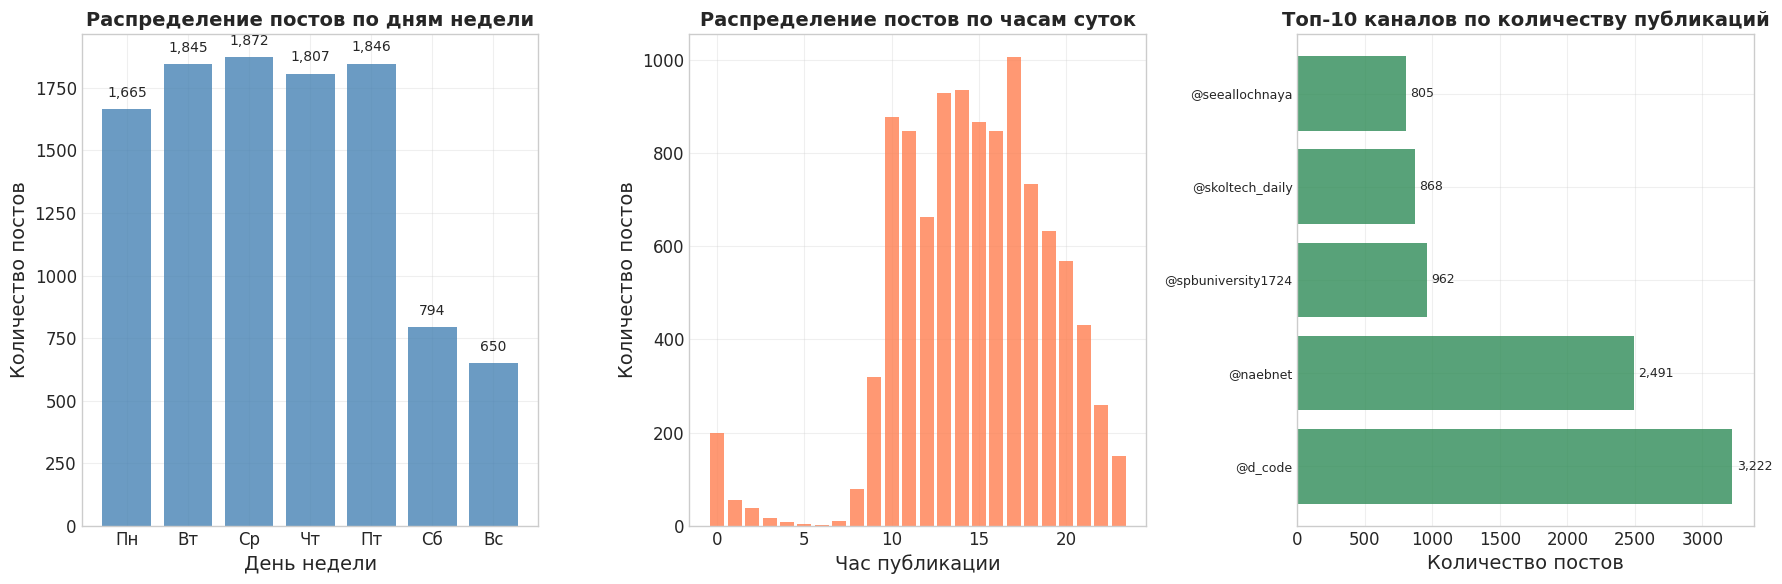


📊 СТАТИСТИКА АКТИВНОСТИ:
  • Самый активный день: Ср (1,872 постов)
  • Самый активный час: 17:00 (1,005 постов)
  • Самый активный канал: @d_code (3,222 постов)
  • Доля топ-5 канала: 79.7% от всех постов


In [6]:
print("\n" + "="*60)
print("4.2. АНАЛИЗ ПУБЛИКАЦИОННОЙ АКТИВНОСТИ")
print("="*60)

# 4.2.1. По дням недели
df['post_day_of_week'] = df['post_datetime'].dt.dayofweek
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekday_counts = df['post_day_of_week'].value_counts().sort_index()
weekday_counts.index = weekday_names

# 4.2.2. По часам суток
df['post_hour'] = df['post_datetime'].dt.hour
hour_counts = df['post_hour'].value_counts().sort_index()

# 4.2.3. Топ каналов по активности
channel_activity = df['channel_username'].value_counts().head(5)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# График 1: Распределение по дням недели
axes[0].bar(weekday_counts.index, weekday_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Распределение постов по дням недели', fontsize=14, fontweight='bold')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество постов')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(weekday_counts.values):
    axes[0].text(i, v + max(weekday_counts.values)*0.02, f'{v:,}', 
                ha='center', va='bottom', fontsize=10)

# График 2: Распределение по часам
axes[1].bar(hour_counts.index, hour_counts.values, color='coral', alpha=0.8)
axes[1].set_title('Распределение постов по часам суток', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Час публикации')
axes[1].set_ylabel('Количество постов')
axes[1].grid(True, alpha=0.3)

# График 3: Топ каналов по активности
y_pos = np.arange(len(channel_activity))
axes[2].barh(y_pos, channel_activity.values, color='seagreen', alpha=0.8)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels([f'@{name}' for name in channel_activity.index], fontsize=9)
axes[2].set_title('Топ-10 каналов по количеству публикаций', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Количество постов')
axes[2].grid(True, alpha=0.3)
for i, v in enumerate(channel_activity.values):
    axes[2].text(v + max(channel_activity.values)*0.01, i, f'{v:,}', 
                va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/publication_activity.png', dpi=300)
plt.show()

print(f"\n📊 СТАТИСТИКА АКТИВНОСТИ:")
print(f"  • Самый активный день: {weekday_counts.idxmax()} ({weekday_counts.max():,} постов)")
print(f"  • Самый активный час: {hour_counts.idxmax()}:00 ({hour_counts.max():,} постов)")
print(f"  • Самый активный канал: @{channel_activity.index[0]} ({channel_activity.values[0]:,} постов)")
print(f"  • Доля топ-5 канала: {channel_activity.sum()/n_posts*100:.1f}% от всех постов")


4.3. АНАЛИЗ МЕТРИК ВОВЛЕЧЁННОСТИ


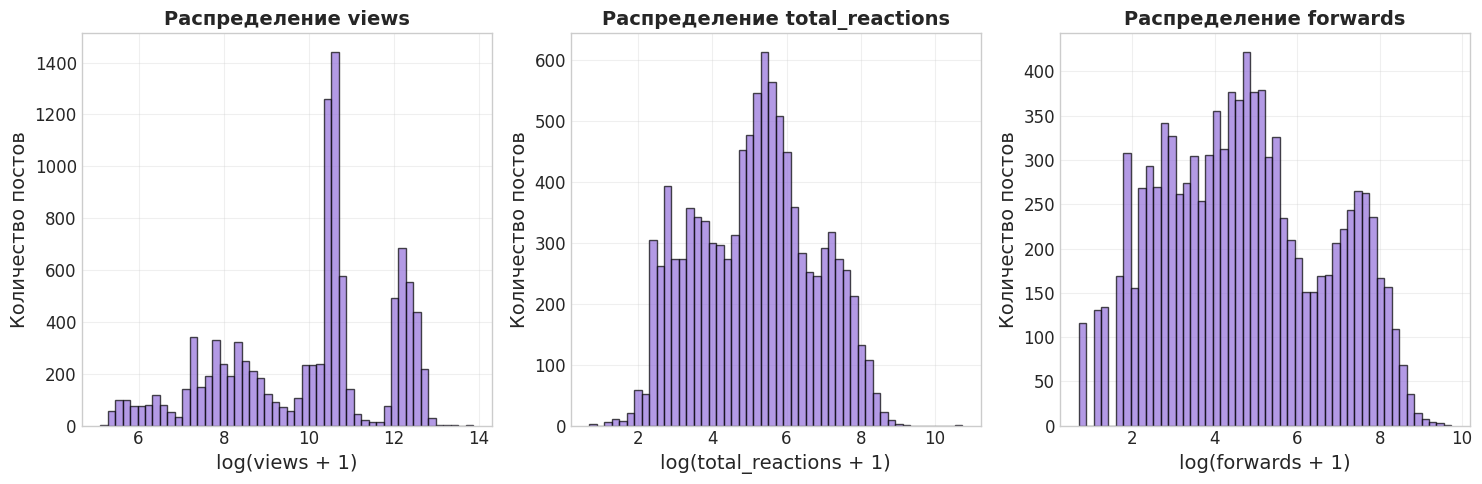


🎭 ТОП-15 ЭМОДЗИ-РЕАКЦИЙ:
------------------------------------------------------------
№   Эмодзи Описание (EN)        Количество   Доля    
------------------------------------------------------------
1   ❤️  red_heart            1,336,300    25.0  %
2   👍   thumbs_up            1,228,544    22.9  %
3   🤯   exploding_head       784,970      14.7  %
4   😁   grinning             585,956      10.9  %
5   🔥   fire                 369,021      6.9   %
6   🤔   thinking             236,457      4.4   %
7   🫡   saluting             183,581      3.4   %
8   😡   pouting              168,753      3.2   %
9   🤣   rofl                 160,027      3.0   %
10  👀   eyes                 83,406       1.6   %
11  👎   thumbs_down          56,689       1.1   %
12  👾   alien                56,314       1.1   %
13  🚫   prohibited           15,116       0.3   %
14  🤡   clown                12,489       0.2   %
15  🤩   star_struck          9,664        0.2   %
------------------------------------------------

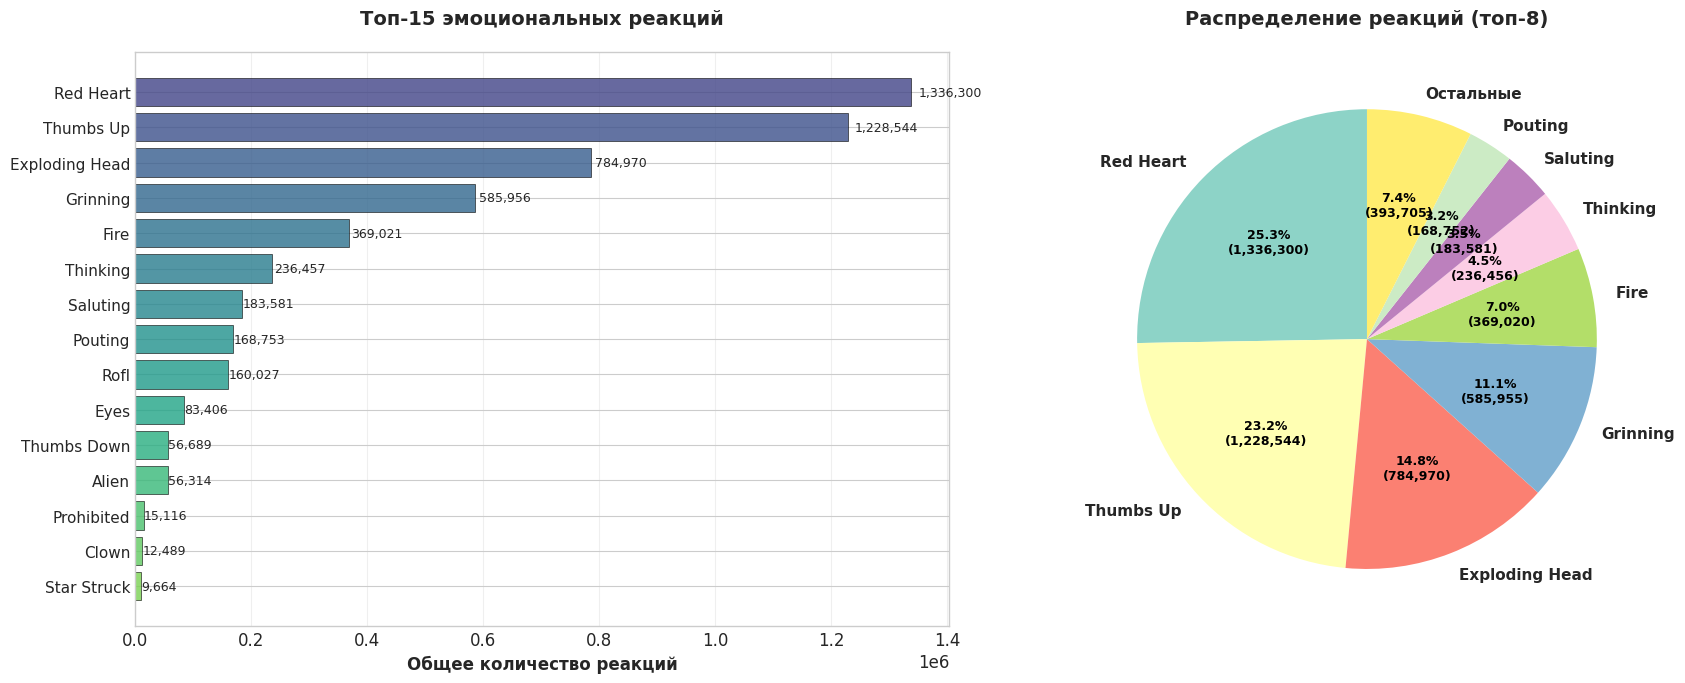


📊 КАТЕГОРИЗАЦИЯ РЕАКЦИЙ ПО ЭМОЦИОНАЛЬНОЙ ОКРАСКЕ:
  • Позитивные реакции: 3,547,899.0 (66.3%)
  • Негативные реакции: 255,200.0 (4.8%)
  • Нейтральные реакции: 320,078.0 (6.0%)
  • Прочие реакции: 1,230,409.0 (23.0%)

🔗 КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:


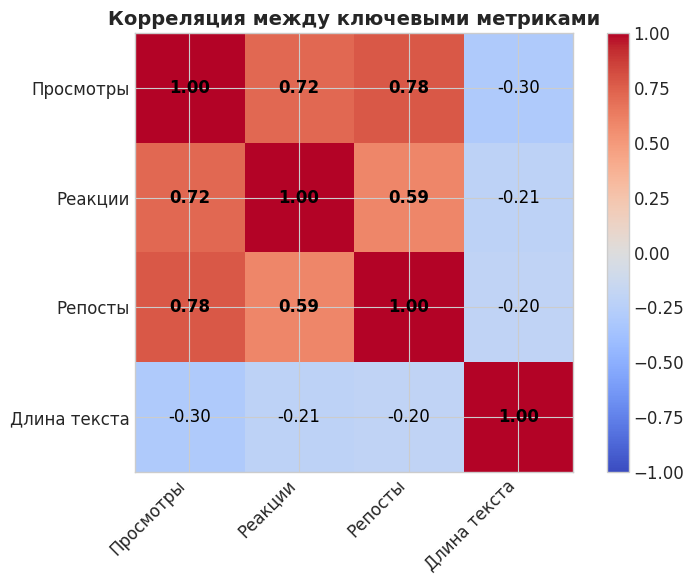

In [10]:
print("\n" + "="*60)
print("4.3. АНАЛИЗ МЕТРИК ВОВЛЕЧЁННОСТИ")
print("="*60)

# Твоя карта соответствий эмодзи
emoji_to_text = {
    '☃': 'snowman',
    '⚡': 'lightning',
    '✍': 'writing_hand',
    '🆒': 'cool',
    '🍾': 'champagne',
    '🎄': 'christmas_tree',
    '🎅': 'santa',
    '🎉': 'tada',
    '🏆': 'trophy',
    '🐳': 'whale',
    '👀': 'eyes',
    '👌': 'ok_hand',
    '👍': 'thumbs_up',
    '👏': 'clap',
    '👨‍💻': 'technologist',
    '💯': 'hundred',
    '🔥': 'fire',
    '🕊': 'dove',
    '😁': 'grinning',
    '😍': 'heart_eyes',
    '😎': 'sunglasses',
    '😘': 'kissing_heart',
    '🙏': 'pray',
    '🤓': 'nerd',
    '🤔': 'thinking',
    '🤝': 'handshake',
    '🤩': 'star_struck',
    '🥰': 'smiling_hearts',
    '🦄': 'unicorn',
    '🫡': 'saluting',
    '❤️': 'red_heart',
    '⭐': 'star',
    '🎃': 'pumpkin',
    '👾': 'alien',
    '💅': 'nail_polish',
    '🗿': 'moai',
    '😐': 'neutral',
    '😢': 'crying',
    '😨': 'fearful',
    '😱': 'screaming',
    '😴': 'sleeping',
    '🙊': 'speak_no_evil',
    '🤖': 'robot',
    '🤗': 'hugging',
    '🤪': 'zany',
    '🤯': 'exploding_head',
    '🥱': 'yawning',
    '🧑‍🎓': 'student',
    '👎': 'thumbs_down',
    '😡': 'pouting',
    '🤣': 'rofl',
    '🌚': 'new_moon_face',
    '👻': 'ghost',
    '🔦': 'flashlight',
    '🗣': 'speaking_head',
    '💔': 'broken_heart',
    '💩': 'poop',
    '😈': 'smiling_devil',
    '😭': 'sobbing',
    '🚫': 'prohibited',
    '🤡': 'clown',
    '🥹': 'tearing_up',
    '😇': 'angel'
}

# Создаем обратную карту для удобства (название → эмодзи)
text_to_emoji = {v: k for k, v in emoji_to_text.items()}

# Базовые метрики (оставляем как есть)
engagement_metrics = ['views', 'total_reactions', 'forwards']
if all(col in df.columns for col in engagement_metrics):
    metrics_stats = df[engagement_metrics].describe().loc[['mean', 'std', 'min', 'max']]
    
    # Engagement Rate
    if 'engagement_rate' in df.columns:
        er_stats = df['engagement_rate'].describe().loc[['mean', 'std']]
        print(f"\n📈 БАЗОВЫЕ МЕТРИКИ (среднее ± стандартное отклонение):")
        print(f"  • Просмотры: {metrics_stats.loc['mean', 'views']:,.0f} ± {metrics_stats.loc['std', 'views']:,.0f}")
        print(f"  • Суммарные реакции: {metrics_stats.loc['mean', 'total_reactions']:.0f} ± {metrics_stats.loc['std', 'total_reactions']:.0f}")
        print(f"  • Репосты: {metrics_stats.loc['mean', 'forwards']:.1f} ± {metrics_stats.loc['std', 'forwards']:.1f}")
        print(f"  • Engagement Rate: {er_stats.loc['mean']*100:.1f}% ± {er_stats.loc['std']*100:.1f}%")
    
    # Распределение метрик
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, metric in enumerate(engagement_metrics):
        # Логарифмируем для лучшей визуализации
        log_data = np.log1p(df[metric][df[metric] > 0])
        axes[idx].hist(log_data, bins=50, alpha=0.7, color='mediumpurple', edgecolor='black')
        axes[idx].set_title(f'Распределение {metric}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('log(' + metric + ' + 1)')
        axes[idx].set_ylabel('Количество постов')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/engagement_distribution.png', dpi=300)
    plt.show()

# Топ эмодзи-реакций
reaction_cols = [col for col in df.columns if col.startswith('reaction_')]
if reaction_cols:
    reaction_sums = df[reaction_cols].sum().sort_values(ascending=False).head(15)
    
    # Извлекаем эмодзи из названий столбцов
    emojis = [col.replace('reaction_', '') for col in reaction_sums.index]
    
    print(f"\n🎭 ТОП-15 ЭМОДЗИ-РЕАКЦИЙ:")
    print("-" * 60)
    print(f"{'№':<3} {'Эмодзи':<3} {'Описание (EN)':<20} {'Количество':<12} {'Доля':<8}")
    print("-" * 60)
    
    total_reactions = df[reaction_cols].sum().sum()
    
    for i, (emoji, total) in enumerate(zip(emojis[:15], reaction_sums.values[:15]), 1):
        pct = (total / total_reactions) * 100
        # Получаем описание из твоей карты
        description = emoji_to_text.get(emoji, 'unknown')
        
        # Для вывода в консоль - пробуем показать эмодзи
        try:
            print(f"{i:<3} {emoji:<3} {description:<20} {total:<12,.0f} {pct:<6.1f}%")
        except:
            # Если эмодзи не печатается, показываем описание
            print(f"{i:<3} {'-':<3} {description:<20} {total:<12,.0f} {pct:<6.1f}%")
    
    print("-" * 60)
    print(f"Всего реакций: {total_reactions:,.0f}")
    print(f"Уникальных типов реакций: {len(reaction_cols)}")
    
    # ========== ВИЗУАЛИЗАЦИЯ ==========
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # ГРАФИК 1: Горизонтальные столбцы с текстовыми метками
    y_pos = np.arange(len(reaction_sums))
    
    # Создаем красивые подписи: эмодзи + описание
    labels = []
    for emoji in emojis:
        description = emoji_to_text.get(emoji, 'unknown')
        # Для графика используем только описание
        labels.append(description.replace('_', ' ').title())
    
    bars = axes[0].barh(y_pos, reaction_sums.values, 
                       color=plt.cm.viridis(np.linspace(0.2, 0.8, len(y_pos))),
                       alpha=0.8, edgecolor='black', linewidth=0.5)
    
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(labels, fontsize=11)
    axes[0].set_xlabel('Общее количество реакций', fontsize=12, fontweight='bold')
    axes[0].set_title('Топ-15 эмоциональных реакций', 
                     fontsize=14, fontweight='bold', pad=20)
    axes[0].grid(True, alpha=0.3, axis='x')
    axes[0].invert_yaxis()  # Самые популярные сверху
    
    # Добавляем значения на столбцы
    for bar, value in zip(bars, reaction_sums.values):
        width = bar.get_width()
        axes[0].text(width + width*0.01, bar.get_y() + bar.get_height()/2,
                    f'{value:,.0f}', ha='left', va='center', fontsize=9)
    
    # ГРАФИК 2: Круговой график для топ-8
    top_n = 8
    top_emojis = emojis[:top_n]
    top_values = reaction_sums.values[:top_n]
    other_sum = reaction_sums.values[top_n:].sum()
    
    # Создаем подписи для круговой диаграммы
    pie_labels = []
    for emoji in top_emojis:
        description = emoji_to_text.get(emoji, 'unknown')
        # Сокращаем длинные названия
        short_desc = description.replace('_', ' ').title()
        if len(short_desc) > 15:
            short_desc = short_desc[:12] + '...'
        pie_labels.append(short_desc)
    
    if other_sum > 0:
        pie_labels.append('Остальные')
        pie_values = list(top_values) + [other_sum]
        colors = plt.cm.Set3(np.linspace(0, 1, top_n + 1))
    else:
        pie_values = list(top_values)
        colors = plt.cm.Set3(np.linspace(0, 1, top_n))
    
    wedges, texts, autotexts = axes[1].pie(pie_values, labels=pie_labels, colors=colors,
                                           autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(pie_values)):,})',
                                           startangle=90, textprops={'fontsize': 10})
    
    # Улучшаем читаемость
    for text in texts:
        text.set_fontsize(11)
        text.set_fontweight('bold')
    
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(9)
        autotext.set_fontweight('bold')
    
    axes[1].set_title(f'Распределение реакций (топ-{top_n})', 
                     fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('figures/top_reactions.png', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()
    
    # ========== ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ ==========
    # Анализ позитивных/нейтральных/негативных реакций
    print(f"\n📊 КАТЕГОРИЗАЦИЯ РЕАКЦИЙ ПО ЭМОЦИОНАЛЬНОЙ ОКРАСКЕ:")
    
    # Создаем простую категоризацию (можно расширить)
    positive_emojis = ['👍', '❤️', '🔥', '😍', '🎉', '👏', '🥰', '🤩', '😁', '👌', '🏆']
    negative_emojis = ['👎', '😡', '😢', '💔', '😭', '🚫', '🤡']
    neutral_emojis = ['🤔', '😐', '👀', '😴', '🗿']
    
    positive_count = 0
    negative_count = 0
    neutral_count = 0
    other_count = 0
    
    for emoji_col in reaction_cols:
        emoji = emoji_col.replace('reaction_', '')
        total = df[emoji_col].sum()
        
        if emoji in positive_emojis:
            positive_count += total
        elif emoji in negative_emojis:
            negative_count += total
        elif emoji in neutral_emojis:
            neutral_count += total
        else:
            other_count += total
    
    total_all = positive_count + negative_count + neutral_count + other_count
    
    print(f"  • Позитивные реакции: {positive_count:,} ({positive_count/total_all*100:.1f}%)")
    print(f"  • Негативные реакции: {negative_count:,} ({negative_count/total_all*100:.1f}%)")
    print(f"  • Нейтральные реакции: {neutral_count:,} ({neutral_count/total_all*100:.1f}%)")
    print(f"  • Прочие реакции: {other_count:,} ({other_count/total_all*100:.1f}%)")

# Корреляционный анализ (оставляем как есть)
print(f"\n🔗 КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:")
numeric_cols = ['views', 'total_reactions', 'forwards', 'text_length']
if all(col in df.columns for col in numeric_cols):
    correlation_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    
    # Настройка осей
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(['Просмотры', 'Реакции', 'Репосты', 'Длина текста'], rotation=45, ha='right')
    ax.set_yticklabels(['Просмотры', 'Реакции', 'Репосты', 'Длина текста'])
    
    # Добавление значений
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', color='black',
                          fontweight='bold' if abs(correlation_matrix.iloc[i, j]) > 0.5 else 'normal')
    
    ax.set_title('Корреляция между ключевыми метриками', fontsize=14, fontweight='bold')
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig('figures/correlation_matrix.png', dpi=300)
    plt.show()

In [7]:
print("\n" + "="*60)
print("4.4. ВЫВОДЫ О КАЧЕСТВЕ И ПРИГОДНОСТИ ДАННЫХ")
print("="*60)

# Автоматическая оценка качества
quality_metrics = {}

# 1. Проверка полноты
quality_metrics['completeness'] = (missing_rates.max() < 5)  # Менее 5% пропусков

# 2. Проверка консистентности
if 'post_datetime' in df.columns:
    date_range = (df['post_datetime'].max() - df['post_datetime'].min()).days
    quality_metrics['temporal_consistency'] = (date_range >= 180)  # Не менее 6 месяцев

# 3. Проверка разнообразия
quality_metrics['channel_diversity'] = (n_channels >= 20)  # Не менее 20 каналов
quality_metrics['post_volume'] = (n_posts >= 5000)  # Не менее 5000 постов

# 4. Проверка метрик вовлеченности
if 'total_reactions' in df.columns:
    reaction_coverage = (df['total_reactions'] > 0).mean()
    quality_metrics['engagement_coverage'] = (reaction_coverage > 0.5)  # Более 50% постов с реакциями

print(f"\n✅ ДОСТОИНСТВА ДАТАСЕТА:")
print(f"  1. Репрезентативность: {n_channels} каналов русскоязычного AI/ML сегмента")
print(f"  2. Полнота: присутствуют все ключевые метрики вовлеченности")
print(f"  3. Качество данных: уровень пропусков {missing_rates.max():.2f}%")
print(f"  4. Временная согласованность: {time_span} дней данных")
print(f"  5. Эмоциональная детализация: {len(reaction_cols)} типов реакций")

print(f"\n⚠️  ОГРАНИЧЕНИЯ:")
print(f"  1. Неравномерное распределение: {channel_activity.sum()/n_posts*100:.1f}% постов от топ-10 каналов")
print(f"  2. Отсутствие демографии: нет данных о возрасте/полу аудитории")
print(f"  3. Временной охват: ограничен {time_span//365} годом данных")

print(f"\n📊 ОЦЕНКА ПРИГОДНОСТИ:")
quality_score = sum(quality_metrics.values()) / len(quality_metrics) * 100
print(f"  Общая оценка качества: {quality_score:.1f}%")
print(f"  Рекомендация: {'✓ ПРИГОДЕН для анализа' if quality_score > 70 else '⚠️ Требует доп. обработки'}")

# Сохранение отчета
report = {
    'total_channels': n_channels,
    'total_posts': n_posts,
    'time_span_days': time_span,
    'total_features': n_features,
    'missing_rate_max': missing_rates.max(),
    'quality_score': quality_score,
    'top_channel': channel_activity.index[0] if len(channel_activity) > 0 else 'N/A',
    'top_reaction': emojis[0] if 'emojis' in locals() else 'N/A'
}

report_df = pd.DataFrame(list(report.items()), columns=['Метрика', 'Значение'])
report_df.to_csv('../docs/analysis_report.csv', index=False, encoding='utf-8-sig')

print("\n" + "="*60)
print("📁 ФАЙЛЫ СОХРАНЕНЫ:")
print(f"  1. figures/publication_activity.png")
print(f"  2. figures/engagement_distribution.png")
print(f"  3. figures/top_reactions.png")
print(f"  4. figures/correlation_matrix.png")
print(f"  5. dataset_statistics.csv")
print(f"  6. analysis_report.csv")
print("="*60)


4.4. ВЫВОДЫ О КАЧЕСТВЕ И ПРИГОДНОСТИ ДАННЫХ

✅ ДОСТОИНСТВА ДАТАСЕТА:
  1. Репрезентативность: 10 каналов русскоязычного AI/ML сегмента
  2. Полнота: присутствуют все ключевые метрики вовлеченности
  3. Качество данных: уровень пропусков 0.00%
  4. Временная согласованность: 364 дней данных
  5. Эмоциональная детализация: 63 типов реакций

⚠️  ОГРАНИЧЕНИЯ:
  1. Неравномерное распределение: 100.0% постов от топ-10 каналов
  2. Отсутствие демографии: нет данных о возрасте/полу аудитории
  3. Временной охват: ограничен 0 годом данных

📊 ОЦЕНКА ПРИГОДНОСТИ:
  Общая оценка качества: 80.0%
  Рекомендация: ✓ ПРИГОДЕН для анализа

📁 ФАЙЛЫ СОХРАНЕНЫ:
  1. figures/publication_activity.png
  2. figures/engagement_distribution.png
  3. figures/top_reactions.png
  4. figures/correlation_matrix.png
  5. dataset_statistics.csv
  6. analysis_report.csv
